In [1]:
%%capture
!pip install pandas matplotlib numpy openpyxl -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

In [3]:
print('Статический парсинг файла Росстата')
print('─' * 55)

df = pd.read_excel('/content/nedel_sred_cen.xlsx',
                   sheet_name='2026',
                   header=3)

name_col = df.iloc[:, 0]
date_cols = df.columns[1:]
print(f'Период: {date_cols[0]} — {date_cols[-1]}')
print(f'Недель в файле: {len(date_cols)}')

def get_price_series(keywords):
    for idx, name in name_col.items():
        if not isinstance(name, str):
            continue
        if all(kw.lower() in name.lower() for kw in keywords):
            series = pd.to_numeric(df.loc[idx].iloc[1:], errors='coerce').dropna()
            return name, series
    return None, None

# Только то что есть в Росстате
SEARCH_MAP = {
    'Куриное филе':       ['кур'],
    'Яйца куриные':       ['яйц'],
    'Огурцы свежие':      ['огурц'],
    'Помидоры свежие':    ['помидор'],
    'Масло подсолнечное': ['масло подсолнечн'],
}

found_prices = {}
found_series = {}

print('\nНайденные позиции:')
for ing_name, kws in SEARCH_MAP.items():
    rosstat_name, series = get_price_series(kws)
    if series is not None and len(series) > 0:
        last_price = series.iloc[-1]
        found_prices[ing_name] = {
            'rosstat_name': rosstat_name,
            'price_kg':     round(last_price, 2),
            'price_100g':   round(last_price / 10, 2),
        }
        found_series[ing_name] = series
        print(f' {ing_name:<25} | {rosstat_name:<40} | {last_price:.2f} ₽/кг')
    else:
        print(f' {ing_name} — не найдено')

Статический парсинг файла Росстата
───────────────────────────────────────────────────────
Период: на 12 января — на 12 мая
Недель в файле: 18

Найденные позиции:
 Куриное филе              | Куры охлажденные и мороженые, кг         | 229.24 ₽/кг
 Яйца куриные              | Яйца куриные, 10 шт.                     | 111.23 ₽/кг
 Огурцы свежие             | Огурцы свежие, кг                        | 151.84 ₽/кг
 Помидоры свежие           | Помидоры свежие, кг                      | 252.02 ₽/кг
 Масло подсолнечное        | Масло подсолнечное, л                    | 153.54 ₽/кг


In [11]:
# Только ингредиенты из Росстата с весами в тарелке 350г
INGREDIENTS = {
    'Куриное филе':       70,
    'Яйца куриные':       30,
    'Огурцы свежие':      35,
    'Помидоры свежие':    50,
    'Масло подсолнечное':  7,
}

rows = []
for name, grams in INGREDIENTS.items():
    if name not in found_prices:
        continue
    p100 = found_prices[name]['price_100g']
    cost = round(p100 * grams / 100, 2)
    rows.append({
        'Ингредиент':          name,
        'Граммов в тарелке':   grams,
        'Цена ₽/100г':         p100,
        'Стоимость в тарелке': cost,
        'Источник':            'Росстат 2026',
    })

df_plate = pd.DataFrame(rows)
total = df_plate['Стоимость в тарелке'].sum()
total_grams = df_plate['Граммов в тарелке'].sum()

print('Себестоимость тарелки (только данные Росстата):')
print('─' * 65)
print(f'{"Ингредиент":<25} {"Граммов":>8} {"₽/100г":>10} {"₽ в тарелке":>13}')
print('─' * 65)
for _, row in df_plate.iterrows():
    print(f'{row["Ингредиент"]:<25} {row["Граммов в тарелке"]:>8} '
          f'{row["Цена ₽/100г"]:>10.2f} {row["Стоимость в тарелке"]:>13.2f}')
print('─' * 65)
print(f'{"Итого":<25} {total_grams:>8} {"":>10} {total:>13.2f} ₽')
print(f'\nСебестоимость {total_grams}г из Росстата: {total:.2f} ₽')
print(f'В пересчёте на 100г: {total/total_grams*100:.2f} ₽')

Себестоимость тарелки (только данные Росстата):
─────────────────────────────────────────────────────────────────
Ингредиент                 Граммов     ₽/100г   ₽ в тарелке
─────────────────────────────────────────────────────────────────
Куриное филе                    70      22.92         16.04
Яйца куриные                    30      11.12          3.34
Огурцы свежие                   35      15.18          5.31
Помидоры свежие                 50      25.20         12.60
Масло подсолнечное               7      15.35          1.07
─────────────────────────────────────────────────────────────────
Итого                          192                    38.36 ₽

Себестоимость 192г из Росстата: 38.36 ₽
В пересчёте на 100г: 19.98 ₽


/tmp/ipykernel_799/845716357.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_plate['Ингредиент'], rotation=20, ha='right', fontsize=10)


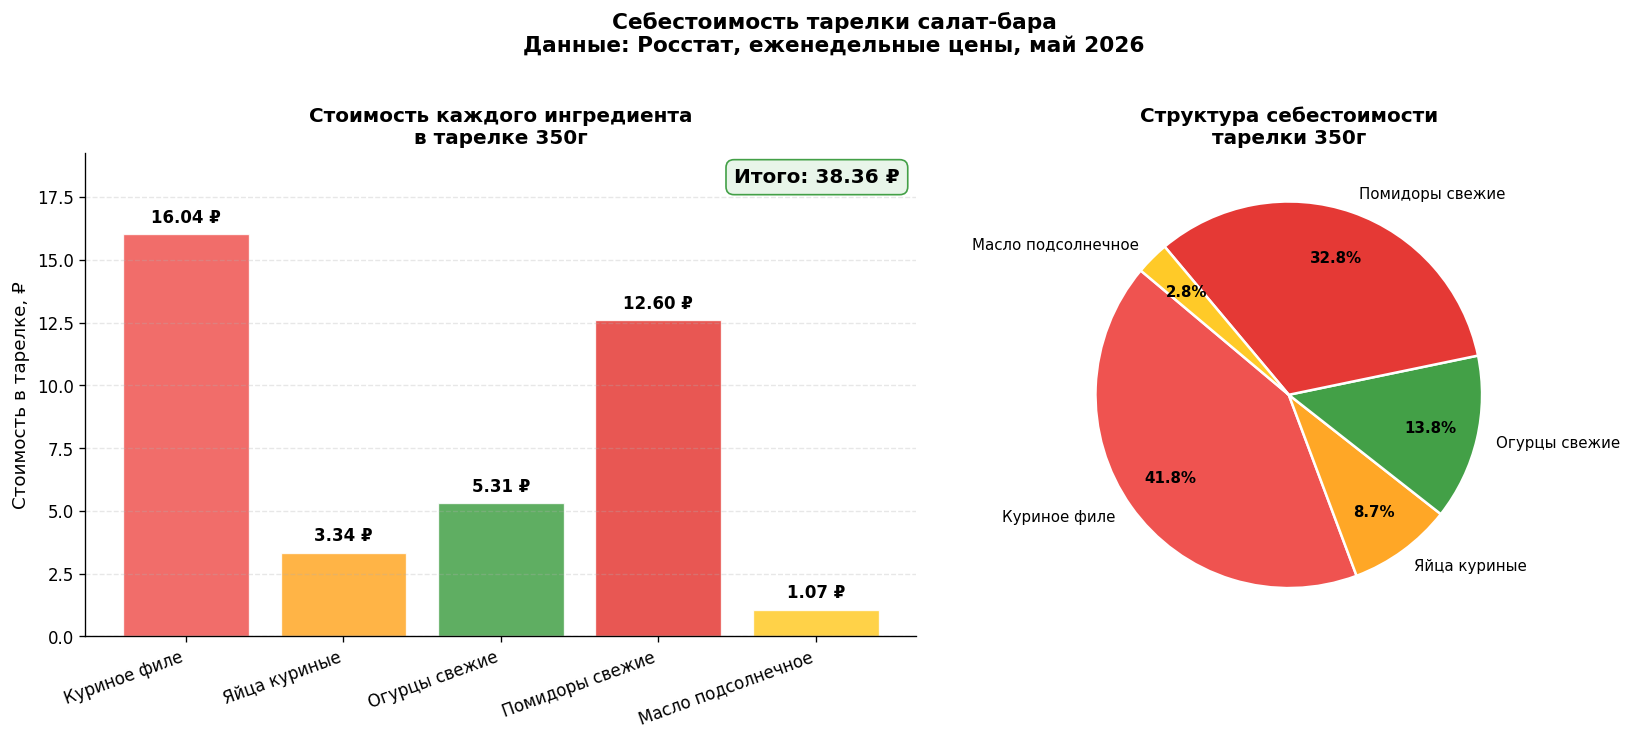

График 1 сохранён


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [1.5, 1]})

colors = ['#EF5350', '#FFA726', '#43A047', '#E53935', '#FFCA28']

# Столбчатая диаграмма
bars = ax1.bar(df_plate['Ингредиент'],
               df_plate['Стоимость в тарелке'],
               color=colors[:len(df_plate)],
               alpha=0.85, edgecolor='white', linewidth=0.8)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{h:.2f} ₽', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax1.set_ylabel('Стоимость в тарелке, ₽', fontsize=11)
ax1.set_title('Стоимость каждого ингредиента\nв тарелке 350г',
              fontsize=12, fontweight='bold')
ax1.set_xticklabels(df_plate['Ингредиент'], rotation=20, ha='right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, df_plate['Стоимость в тарелке'].max() * 1.2)

# Текст с итогом
ax1.text(0.98, 0.97, f'Итого: {total:.2f} ₽',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#43A047'))

# Круговая диаграмма
wedges, texts, autotexts = ax2.pie(
    df_plate['Стоимость в тарелке'],
    labels=df_plate['Ингредиент'],
    colors=colors[:len(df_plate)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
for t in texts:
    t.set_fontsize(9)

ax2.set_title('Структура себестоимости\nтарелки 350г',
              fontsize=12, fontweight='bold')

fig.suptitle('Себестоимость тарелки салат-бара\nДанные: Росстат, еженедельные цены, май 2026',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart1_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('График 1 сохранён')

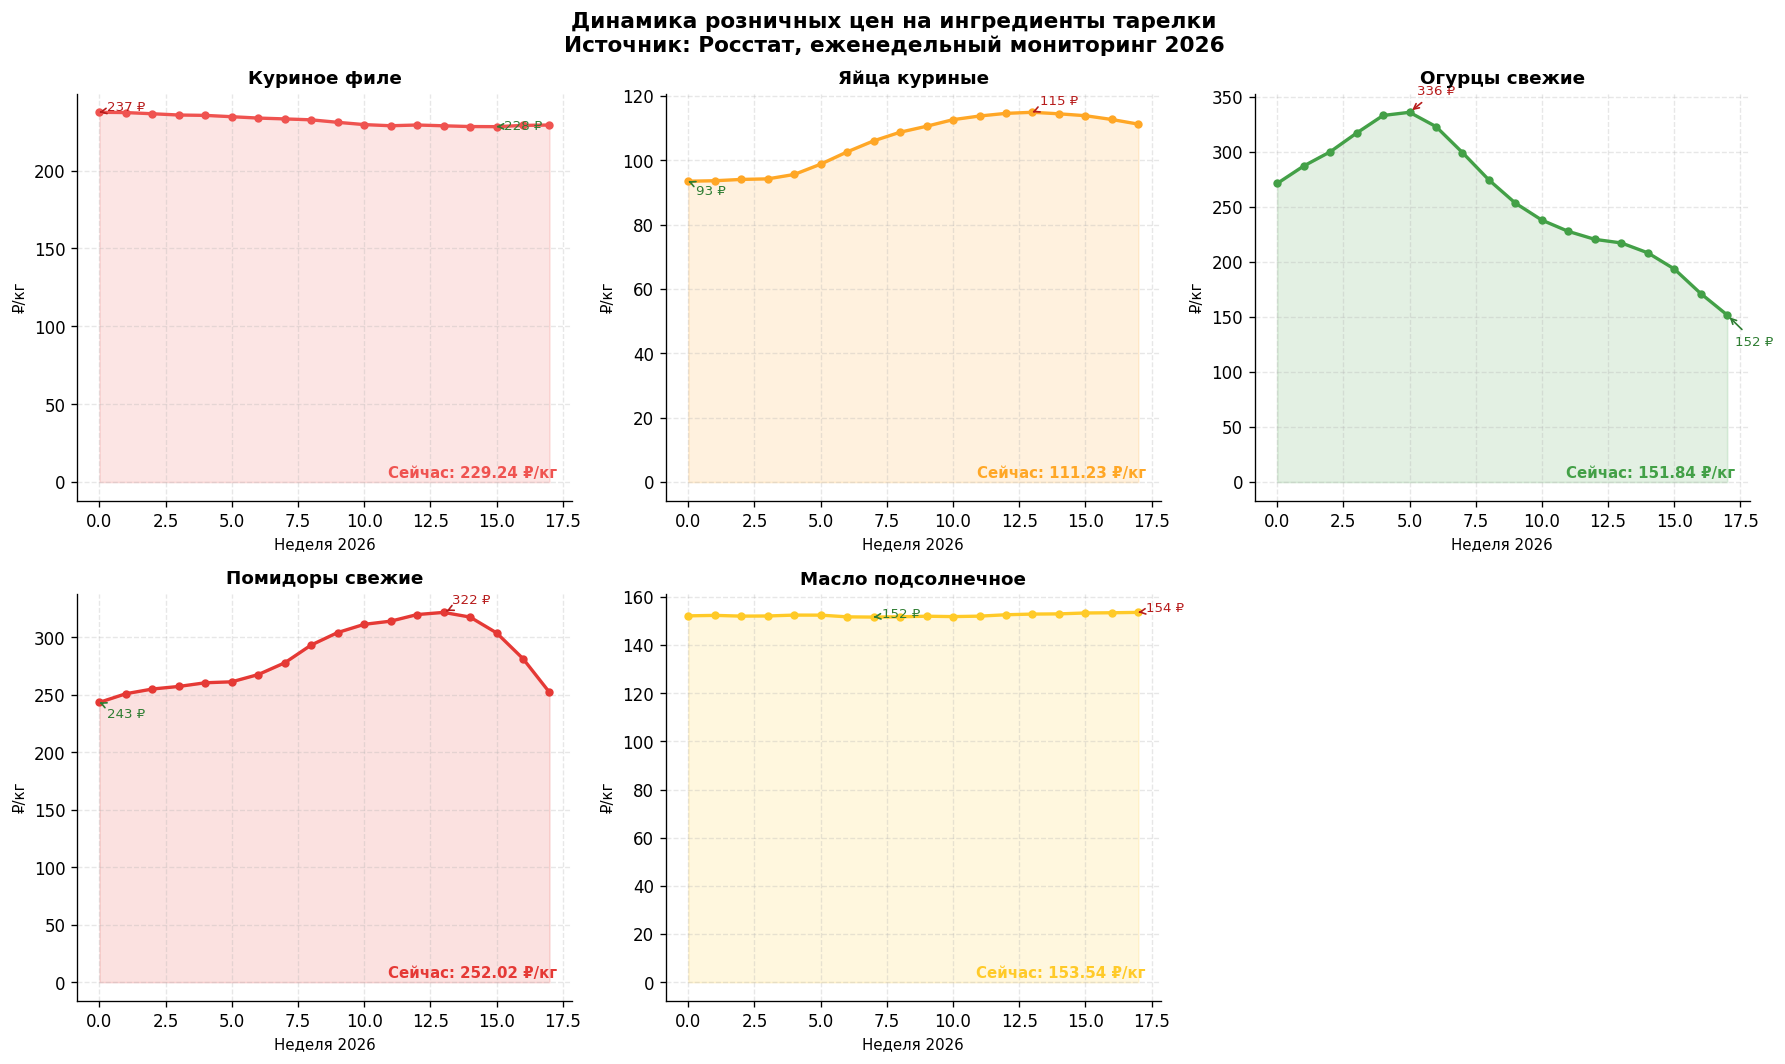

График 2 сохранён


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_colors = {
    'Куриное филе':       '#EF5350',
    'Яйца куриные':       '#FFA726',
    'Огурцы свежие':      '#43A047',
    'Помидоры свежие':    '#E53935',
    'Масло подсолнечное': '#FFCA28',
}

for i, (ing_name, series) in enumerate(found_series.items()):
    ax = axes[i]
    color = plot_colors.get(ing_name, '#999')
    weeks = list(range(len(series)))
    values = series.values

    ax.plot(weeks, values, 'o-', color=color, lw=2, ms=4)
    ax.fill_between(weeks, values, alpha=0.15, color=color)

    # Мин и макс
    mn_i = int(np.argmin(values))
    mx_i = int(np.argmax(values))
    ax.annotate(f'{values[mn_i]:.0f} ₽',
                xy=(mn_i, values[mn_i]),
                xytext=(mn_i+0.3, values[mn_i]-values.std()*0.5),
                fontsize=8, color='#2E7D32',
                arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1))
    ax.annotate(f'{values[mx_i]:.0f} ₽',
                xy=(mx_i, values[mx_i]),
                xytext=(mx_i+0.3, values[mx_i]+values.std()*0.3),
                fontsize=8, color='#B71C1C',
                arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1))

    ax.set_title(ing_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Неделя 2026', fontsize=9)
    ax.set_ylabel('₽/кг', fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Подпись последней цены
    ax.text(0.97, 0.05, f'Сейчас: {values[-1]:.2f} ₽/кг',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color=color, fontweight='bold')

# Скрываем пустой 6-й subplot
axes[5].set_visible(False)

fig.suptitle('Динамика розничных цен на ингредиенты тарелки\n'
             'Источник: Росстат, еженедельный мониторинг 2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print('График 2 сохранён')